# Employee Attrition Analysis and Prediction

## Business Problem

Employee attrition is a major challenge for organizations because replacing employees is costly and affects productivity. This project aims to analyze employee data, identify the factors influencing attrition, and build predictive models to help HR teams make informed decisions.

## Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Overview

In [6]:
print("Rows and Columns:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Rows and Columns: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## Data Inspection

Before performing data cleaning and analysis, we need to understand the structure, quality, and characteristics of the dataset.

In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
# Statistical summary
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
# Statistical summary for categorical columns
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [10]:
# Check missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [12]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
# Display data types
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


### Observations

- The dataset contains **1,470 employee records** and **35 columns**.
- There are **no missing values**, so data imputation is not required.
- There are **no duplicate records**, indicating good data quality.
- The target variable is **Attrition**, which indicates whether an employee has left the organization.
- The dataset contains a mix of numerical and categorical features, which will require preprocessing before building machine learning models.

In [16]:
for col in ["EmployeeCount", "Over18", "StandardHours"]:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-"*30)

EmployeeCount:
EmployeeCount
1    1470
Name: count, dtype: int64
------------------------------
Over18:
Over18
Y    1470
Name: count, dtype: int64
------------------------------
StandardHours:
StandardHours
80    1470
Name: count, dtype: int64
------------------------------


### Removing Unnecessary Columns

Some columns do not contribute meaningful information for predicting employee attrition.

- **EmployeeCount** has the same value for every employee.
- **Over18** contains only one category ('Y').
- **StandardHours** is constant across all records.
- **EmployeeNumber** is a unique identifier and does not influence employee attrition.

These columns are removed to simplify the dataset and improve model performance.

In [17]:
df.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [18]:
df.shape

(1470, 31)

In [19]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset by identifying trends, patterns, and relationships between variables. The goal is to discover the factors that influence employee attrition and generate meaningful business insights.

## 6.1 Employee Attrition Distribution

The first step is to understand the overall distribution of employees who stayed versus those who left the organization.

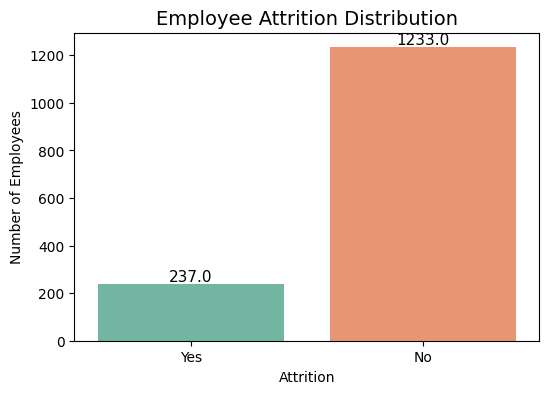

In [20]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Attrition', data=df, palette='Set2')

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

plt.title("Employee Attrition Distribution", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [21]:
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_percentage)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### Business Insight

- Approximately **84%** of employees remained with the company, while around **16%** left.
- Although attrition is relatively low, losing skilled employees can significantly increase recruitment costs and impact productivity.
- Since the classes are slightly imbalanced, evaluation metrics such as **Recall**, **F1-score**, and **ROC-AUC** will be more informative than accuracy alone.

## 6.2 Age Distribution

Let's examine the age distribution of employees to understand the workforce demographics.

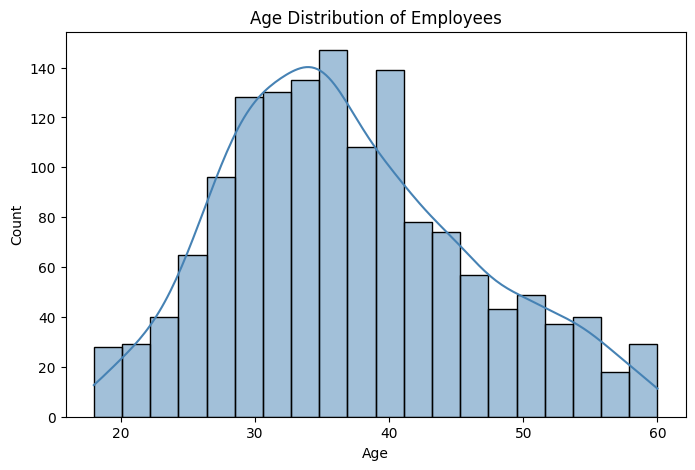

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [23]:
df['Age'].describe()

,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000


### Business Insight

- Most employees fall between **30 and 40 years** of age.
- Understanding the age distribution helps HR identify whether younger or older employees are more likely to leave, which will be explored in later analyses.

## 6.3 Attrition by Gender

This analysis examines whether employee attrition differs between male and female employees.

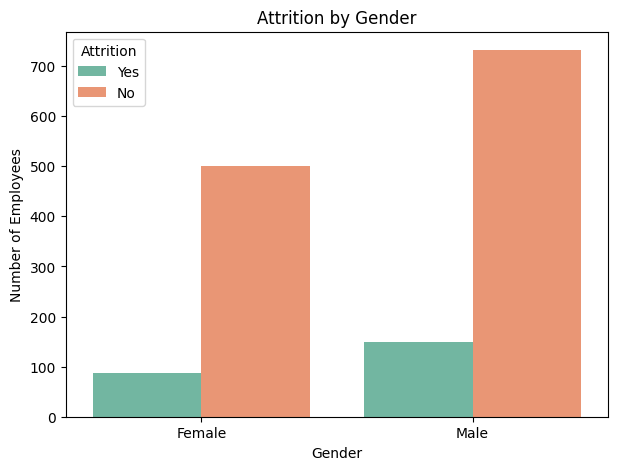

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(x='Gender', hue='Attrition', data=df, palette='Set2')

plt.title("Attrition by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()

In [25]:
pd.crosstab(df['Gender'], df['Attrition'])

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


### Business Insight

- Both male and female employees experience attrition.
- Comparing attrition across genders helps determine whether targeted retention strategies are needed.

## 6.4 Attrition by Department

Departments may experience different levels of employee turnover. Identifying high-attrition departments helps HR prioritize retention efforts.

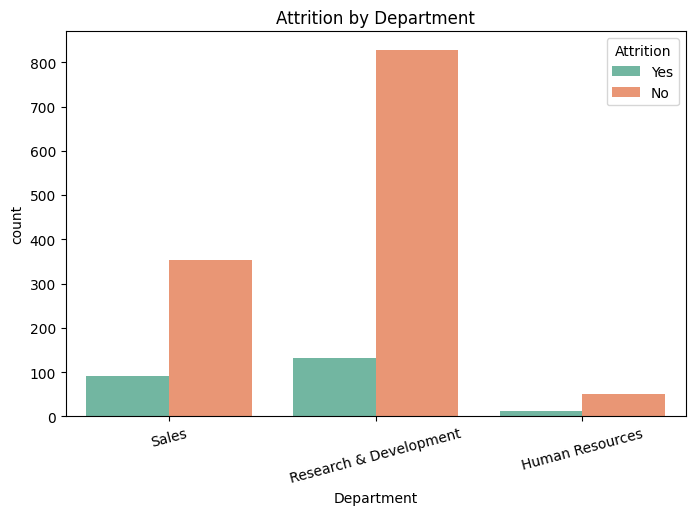

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x='Department',
              hue='Attrition',
              data=df,
              palette='Set2')

plt.xticks(rotation=15)

plt.title("Attrition by Department")

plt.show()

In [27]:
pd.crosstab(df['Department'], df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


### Business Insight

- Departments with higher attrition may require improved employee engagement, workload balancing, or career development opportunities.
- HR can use this information to focus retention initiatives on departments with the highest turnover.

## 6.5 OverTime vs Attrition

This analysis examines whether employees who work overtime are more likely to leave the organization.

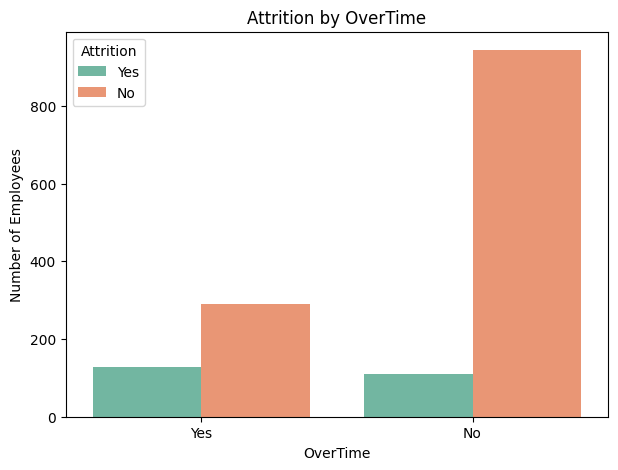

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition',
    palette='Set2'
)

plt.title("Attrition by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.show()

In [29]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


### Business Insight

- Employees who work overtime show a noticeably higher attrition rate.
- Excessive overtime may contribute to employee burnout and reduced work-life balance.
- HR should monitor overtime workloads and consider policies to reduce excessive overtime.

## 6.6 Monthly Income vs Attrition

This analysis investigates whether employee salary influences attrition.

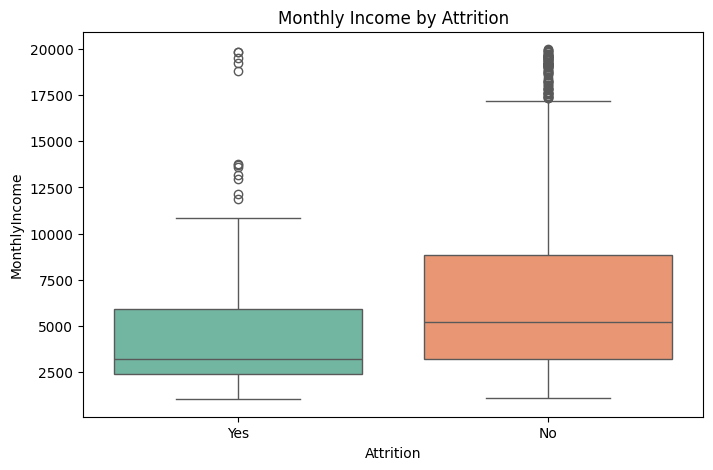

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    palette='Set2'
)

plt.title("Monthly Income by Attrition")

plt.show()

### Business Insight

- Employees who left the organization generally have lower median monthly income.
- Competitive compensation may help improve employee retention.
- Salary should be considered along with other factors such as job satisfaction and overtime.

## 6.7 Job Satisfaction vs Attrition

Employee satisfaction often plays an important role in retention. This analysis explores the relationship between job satisfaction and attrition.

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='JobSatisfaction',
    hue='Attrition',
    palette='Set2'
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

In [31]:
pd.crosstab(df['JobSatisfaction'], df['Attrition'])

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


### Business Insight

- Employees with lower job satisfaction appear more likely to leave.
- Improving employee engagement and career growth opportunities may reduce attrition.

## 6.8 Business Travel vs Attrition

Frequent business travel can affect employee well-being and work-life balance.

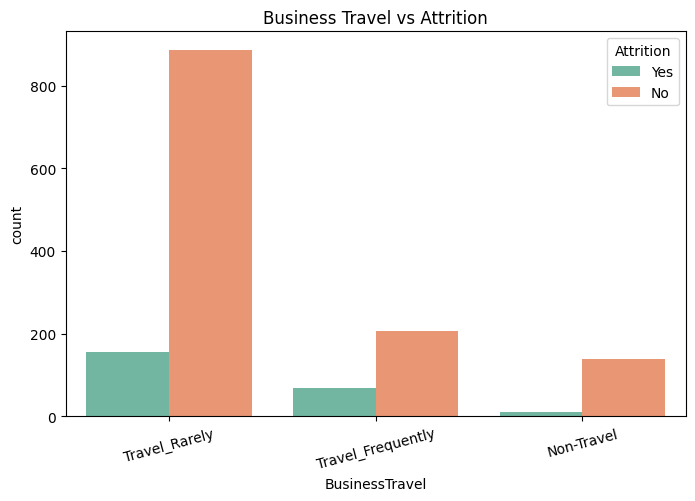

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='BusinessTravel',
    hue='Attrition',
    palette='Set2'
)

plt.title("Business Travel vs Attrition")

plt.xticks(rotation=15)

plt.show()

In [33]:
pd.crosstab(df['BusinessTravel'], df['Attrition'])

Attrition,No,Yes
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,208,69
Travel_Rarely,887,156


### Business Insight

- Employees who travel frequently tend to have higher attrition.
- Organizations should ensure that frequent travelers receive adequate support and work-life balance initiatives.

## 6.9 Job Role vs Attrition

Different job roles may experience different levels of employee turnover.

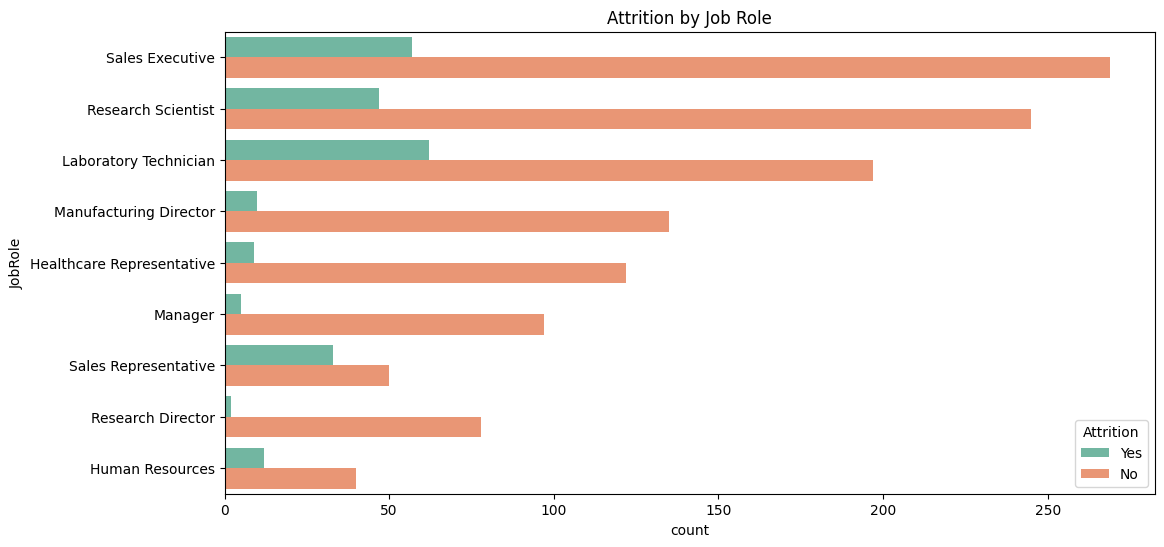

In [34]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='JobRole',
    hue='Attrition',
    palette='Set2'
)

plt.title("Attrition by Job Role")

plt.show()

In [35]:
pd.crosstab(df['JobRole'], df['Attrition'])

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


### Business Insight

- Some job roles experience noticeably higher employee turnover than others.
- HR can prioritize retention strategies for roles with consistently high attrition.

## 6.10 Correlation Heatmap

The correlation heatmap helps identify relationships among numerical variables. Strong correlations can reveal patterns and potential multicollinearity.

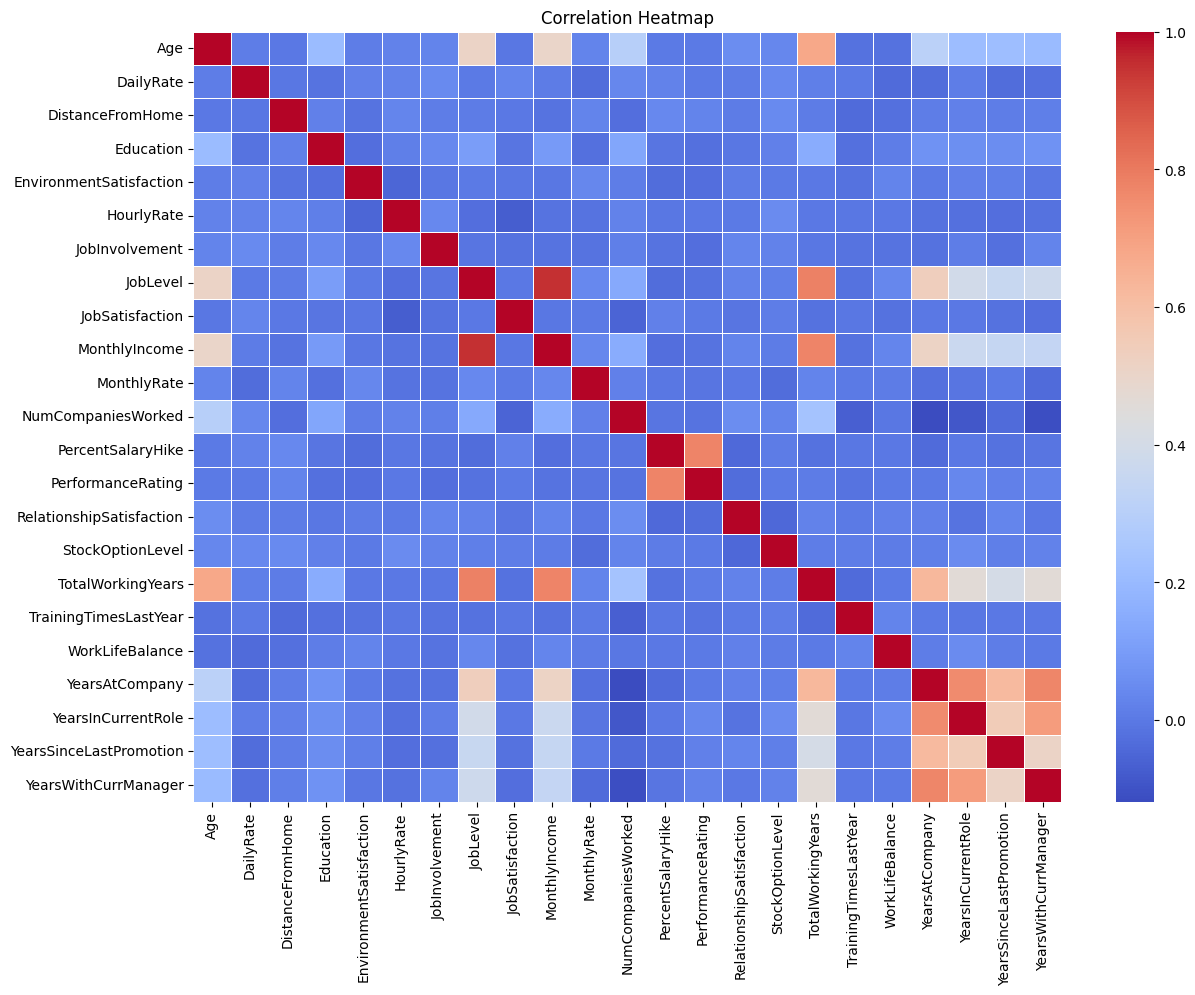

In [36]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# Data Preprocessing
Preparing the dataset for machine learning by encoding categorical variables and splitting the data.

## Encode Target Variable

In [37]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

df['Attrition'].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


## Encode Categorical Features

In [38]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [39]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [40]:
print(df.shape)

(1470, 45)


## Split Features and Target

In [41]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

## Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


# Machine Learning Models
Training multiple classification models for predicting employee attrition.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [47]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.8639455782312925
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       247
           1       0.82      0.19      0.31        47

    accuracy                           0.86       294
   macro avg       0.84      0.59      0.62       294
weighted avg       0.86      0.86      0.83       294



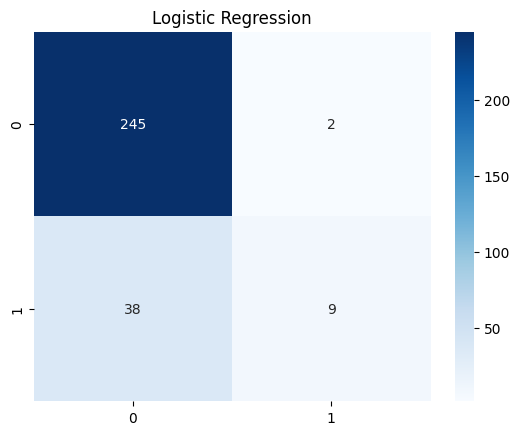

In [48]:
sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression")

plt.show()

In [49]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy: 0.7653061224489796
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       247
           1       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294



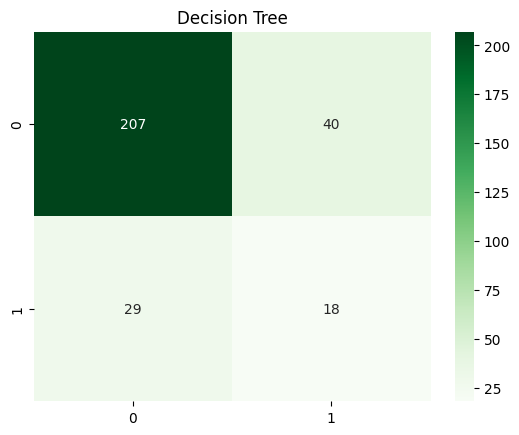

In [50]:
sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree")

plt.show()

In [51]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



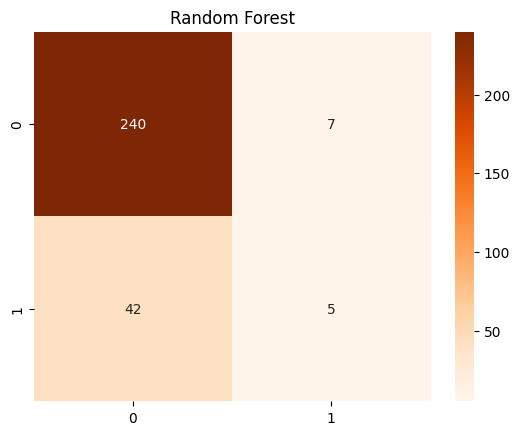

In [52]:
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest")

plt.show()

# Model Comparison

In [53]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.863946
2,Random Forest,0.833333
1,Decision Tree,0.765306


# Feature Importance

In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.072306
0,Age,0.072260
16,TotalWorkingYears,0.053589
1,DailyRate,0.051670
5,HourlyRate,0.047866
2,DistanceFromHome,0.047793
10,MonthlyRate,0.047228
19,YearsAtCompany,0.044137
43,OverTime_Yes,0.037830
22,YearsWithCurrManager,0.035452


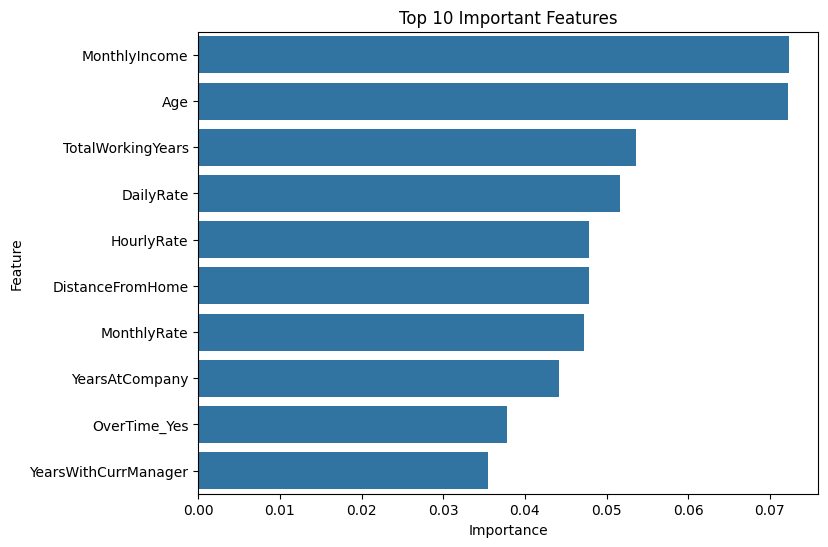

In [55]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Business Recommendations

- Reduce excessive overtime.
- Improve work-life balance.
- Increase employee engagement.
- Review compensation for lower-income employees.
- Develop retention strategies for high-risk job roles.

# Conclusion

This project analyzed employee attrition using exploratory data analysis and machine learning. Random Forest achieved the best performance and identified key factors influencing employee turnover. These insights can help HR departments develop effective employee retention strategies.